<a href="https://colab.research.google.com/github/Lavanya-S-code/ML-lab-exp/blob/main/ML_Lab_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.decomposition import PCA

In [2]:
X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [3]:
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

In [4]:
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train_2d, y_train)

RandomForestClassifier(random_state=42)

In [5]:
ada_clf = AdaBoostClassifier(random_state=42)
ada_clf.fit(X_train_2d, y_train)

AdaBoostClassifier(random_state=42)

In [6]:
def plot_decision_boundaries(clf, X, y, ax, title):
  h = .02 # Step size in the mesh
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h))
  Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  ax.contourf(xx, yy, Z, alpha=0.3)
  ax.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o')
  ax.set_title(title)

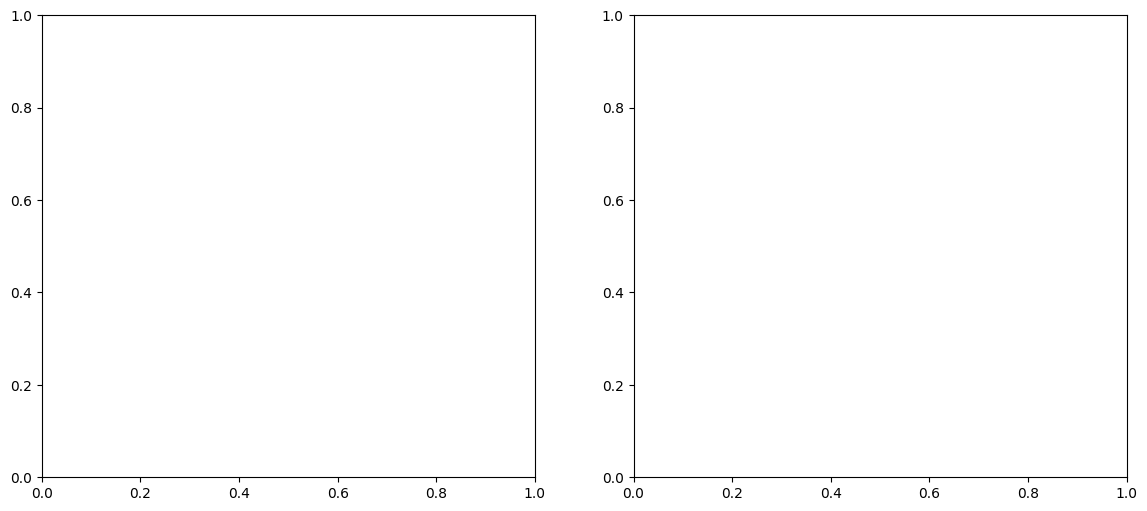

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

In [8]:
plot_decision_boundaries(rf_clf, X_test_2d, y_test, axs[0], 'Random Forest')

In [9]:
plot_decision_boundaries(ada_clf, X_test_2d, y_test, axs[1], 'AdaBoost')
plt.show()